# Noble Addis: Machine Learning Notebook

This notebook documents the machine learning work behind **Noble Addis**, a real estate platform focused on making property search and pricing in Addis Ababa more transparent and data-driven.

The main goal of this notebook is to build, test, and compare different machine learning models for property price prediction. The final model will support the platform by helping users estimate fair property prices based on features such as location, property size, number of bedrooms, bathrooms, and other available details.

The notebook focuses on:

- understanding the dataset
- cleaning and preparing the data
- training multiple machine learning models
- comparing model performance
- selecting the best-performing model
- saving the final model for use in the Noble Addis application

## 1. Project Context

Real estate pricing in Addis Ababa is not always easy for buyers, renters, sellers, or investors to understand. Prices can vary widely depending on location, property type, size, condition, and market demand. In many cases, users depend on informal estimates, agent opinions, or incomplete listing information.

Noble Addis aims to reduce this uncertainty by introducing a data-driven layer into the property search process. Instead of only displaying listings, the platform also uses machine learning to support better decision-making.

For this notebook, the machine learning task is treated as a supervised regression problem. The model learns patterns from existing property data and uses those patterns to estimate the expected price of a property.

## 2. Machine Learning Objective

The main objective is to predict the price of a property using the available listing features.

In simple terms, the model should answer this question:

> Given the details of a property, what is a reasonable estimated price?

This is important because a price prediction model can help:

- buyers compare listed prices against estimated market values
- sellers understand whether their property is underpriced or overpriced
- the platform flag unusual or suspicious listings in future versions
- users make more informed decisions before contacting agents or owners

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Model preparation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Saving the final model
import joblib

# Keep results stable when the notebook is re-run
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Dataset Loading

The dataset was prepared from Noble Addis property listing data and saved as `addis_model_ready.csv`.

For this notebook, the file is uploaded directly into Google Colab so that the machine learning pipeline can be trained and tested in the same environment.

In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded.")
print(f"File used: {file_name}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()

Saving addis_model_ready.csv to addis_model_ready.csv
Dataset loaded.
File used: addis_model_ready.csv
Rows: 85400
Columns: 23


,price,listed_price,price_sqm,price_per_sqm,property_type,listing_type,size_sqm,latitude,longitude,address,address_main,place_name,bathrooms,bedrooms,image_count,floor,features,condition,furnishing,description_length,has_image,completeness_score,risk_label
0,"9,500,000.00","2,590,673.58","76,000.00","20,725.39",house,for sale,125.00,9.02,38.87,አያት,ayat square addis ababa,Unknown,0.00,0.00,3.00,NaN,Unknown,Unknown,no,10,1,0.70,normal
1,"8,000,000.00","2,181,619.85","74,766.36","20,388.97",apartment,for sale,107.00,9.01,38.88,አያት ቁጥር 3 20/80 ኮንደምኔም,ayat zone 3 addis ababa,"2V7G+2MJ, Addis Ababa, Ethiopia",1.00,3.00,4.00,NaN,parking space,new,no,36,1,0.90,normal
2,"9,350,000.00","2,549,768.20","85,000.00","23,179.71",apartment,for sale,110.00,9.00,38.87,ሰሚት 72,fiyel semit 72 addis ababa,"2V29+J4, Addis Ababa, Ethiopia",2.00,2.00,3.00,NaN,spacious shared terrace;modern elevators;backu...,Unknown,no,63,1,1.00,normal
3,"6,000,000.00","1,636,214.89","139,534.88","38,051.51",apartment,for sale,43.00,8.98,38.76,ጎተራ ኮንዶሚኔም,gotera condominium addis ababa,"Gotera Condominium, Addis Ababa, Ethiopia",1.00,1.00,7.00,NaN,Unknown,Unknown,no,17,1,0.90,normal
4,"5,200,000.00","1,418,052.90","75,362.32","20,551.49",land,for sale,69.00,8.98,38.89,ቦሌ አራብሳ,bole arabsa condominium addis ababa,"XVGQ+X4R, Addis Ababa, Ethiopia",1.00,2.00,3.00,NaN,Unknown,new,no,14,1,0.90,normal


## 4. Initial Data Exploration

Before building any machine learning model, it is important to understand the dataset.

Exploring the data helps identify the types of variables available, detect missing values, understand the distribution of numerical features, and reveal any potential issues that could affect model performance.

This stage also provides useful insights into the overall quality of the dataset before any preprocessing begins.

In [3]:
# Display the first five observations
df.head()

,price,listed_price,price_sqm,price_per_sqm,property_type,listing_type,size_sqm,latitude,longitude,address,address_main,place_name,bathrooms,bedrooms,image_count,floor,features,condition,furnishing,description_length,has_image,completeness_score,risk_label
0,"9,500,000.00","2,590,673.58","76,000.00","20,725.39",house,for sale,125.00,9.02,38.87,አያት,ayat square addis ababa,Unknown,0.00,0.00,3.00,NaN,Unknown,Unknown,no,10,1,0.70,normal
1,"8,000,000.00","2,181,619.85","74,766.36","20,388.97",apartment,for sale,107.00,9.01,38.88,አያት ቁጥር 3 20/80 ኮንደምኔም,ayat zone 3 addis ababa,"2V7G+2MJ, Addis Ababa, Ethiopia",1.00,3.00,4.00,NaN,parking space,new,no,36,1,0.90,normal
2,"9,350,000.00","2,549,768.20","85,000.00","23,179.71",apartment,for sale,110.00,9.00,38.87,ሰሚት 72,fiyel semit 72 addis ababa,"2V29+J4, Addis Ababa, Ethiopia",2.00,2.00,3.00,NaN,spacious shared terrace;modern elevators;backu...,Unknown,no,63,1,1.00,normal
3,"6,000,000.00","1,636,214.89","139,534.88","38,051.51",apartment,for sale,43.00,8.98,38.76,ጎተራ ኮንዶሚኔም,gotera condominium addis ababa,"Gotera Condominium, Addis Ababa, Ethiopia",1.00,1.00,7.00,NaN,Unknown,Unknown,no,17,1,0.90,normal
4,"5,200,000.00","1,418,052.90","75,362.32","20,551.49",land,for sale,69.00,8.98,38.89,ቦሌ አራብሳ,bole arabsa condominium addis ababa,"XVGQ+X4R, Addis Ababa, Ethiopia",1.00,2.00,3.00,NaN,Unknown,new,no,14,1,0.90,normal


The first few records give an overview of the information collected for each property listing. The dataset includes both numerical and categorical variables describing different aspects of a property, including its location, physical characteristics, listing information, and price.

The target variable for this project is **price**, while the remaining columns will be used as predictor variables during model training.

In [4]:
# Dataset dimensions

print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 85,400
Number of columns : 23


In [5]:
# Display column names

df.columns.tolist()

['price',
 'listed_price',
 'price_sqm',
 'price_per_sqm',
 'property_type',
 'listing_type',
 'size_sqm',
 'latitude',
 'longitude',
 'address',
 'address_main',
 'place_name',
 'bathrooms',
 'bedrooms',
 'image_count',
 'floor',
 'features',
 'condition',
 'furnishing',
 'description_length',
 'has_image',
 'completeness_score',
 'risk_label']

In [6]:
# View data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85400 entries, 0 to 85399
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               85400 non-null  float64
 1   listed_price        85400 non-null  float64
 2   price_sqm           85400 non-null  float64
 3   price_per_sqm       85400 non-null  float64
 4   property_type       85400 non-null  object 
 5   listing_type        85400 non-null  object 
 6   size_sqm            85400 non-null  float64
 7   latitude            85400 non-null  float64
 8   longitude           85400 non-null  float64
 9   address             85400 non-null  object 
 10  address_main        85400 non-null  object 
 11  place_name          85400 non-null  object 
 12  bathrooms           85400 non-null  float64
 13  bedrooms            85400 non-null  float64
 14  image_count         85400 non-null  float64
 15  floor               833 non-null    float64
 16  feat

In [7]:
# Summary statistics for numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,"85,400.00","9,902,914.63","13,059,896.72","1,500.00","2,100,000.00","5,900,000.00","13,000,000.00","230,000,000.00"
listed_price,"85,400.00","3,260,647.63","4,025,988.98",856.03,"732,341.13","2,133,534.14","4,276,114.84","71,902,654.87"
price_sqm,"85,400.00","60,114.15","53,506.06",30.00,"18,181.82","49,550.00","90,629.57","571,428.57"
price_per_sqm,"85,400.00","19,337.04","15,463.00",25.08,"7,513.15","17,838.74","27,991.16","149,253.73"
size_sqm,"85,400.00",168.77,101.35,25.00,100.00,148.00,207.00,500.00
latitude,"85,400.00",9.00,0.04,8.83,8.98,9.00,9.02,9.12
longitude,"85,400.00",38.80,0.05,38.64,38.77,38.79,38.85,38.91
bathrooms,"85,400.00",1.75,1.77,0.00,0.00,2.00,3.00,50.00
bedrooms,"85,400.00","10,783.30","3,150,509.89",0.00,1.00,2.00,3.00,"920,682,278.00"
image_count,"85,400.00",4.90,3.52,0.00,2.00,4.00,7.00,37.00


In [8]:
# Summary of categorical variables

df.describe(include="object").T

,count,unique,top,freq
property_type,85400,6,apartment,38241
listing_type,85400,2,for sale,69258
address,85400,12184,Addis Ababa,18701
address_main,85400,15326,bole,7540
place_name,85400,3302,Unknown,8784
features,85400,22922,Unknown,38398
condition,85400,4,Unknown,56107
furnishing,85400,4,no,68517
risk_label,85400,2,normal,68320


## 5. Data Quality Assessment

Before cleaning the dataset, I first checked the quality of the data. This step is important because missing values, duplicated records, unusual values, or poorly formatted columns can affect the accuracy of the model.

The goal here is not to change the data immediately, but to understand where the main issues are and decide how they should be handled.

In [9]:
# Check missing values in each column

missing_summary = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values("missing_percentage", ascending=False)
missing_summary

,missing_values,missing_percentage
floor,84567,99.02
listed_price,0,0.00
price,0,0.00
price_per_sqm,0,0.00
property_type,0,0.00
listing_type,0,0.00
price_sqm,0,0.00
size_sqm,0,0.00
latitude,0,0.00
address,0,0.00


The missing value summary helps identify which columns are complete and which ones may require cleaning.

Columns with very high missing values may not be reliable for model training unless they are important enough to keep and can be filled in a reasonable way.

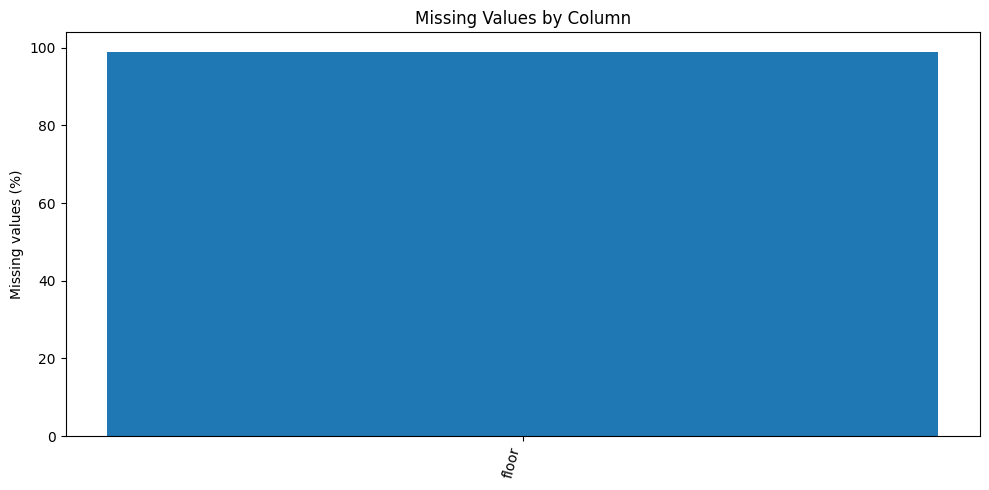

In [10]:
# Plot missing values for columns that have at least one missing value

missing_to_plot = missing_summary[missing_summary["missing_values"] > 0]

plt.figure(figsize=(10, 5))
plt.bar(missing_to_plot.index, missing_to_plot["missing_percentage"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Missing values (%)")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

In [11]:
# Check duplicated rows

duplicate_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_count:,}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicated rows: 2,902
Duplicate percentage: 3.40%


In [12]:
# Check unique values in each column

unique_summary = pd.DataFrame({
    "unique_values": df.nunique()
}).sort_values("unique_values", ascending=False)

unique_summary

,unique_values
price_per_sqm,43715
features,22922
listed_price,20305
price_sqm,17147
address_main,15326
address,12184
price,6659
longitude,6107
latitude,6043
place_name,3302


In [13]:
# Check the target variable

df["price"].describe()

,price
count,"85,400.00"
mean,"9,902,914.63"
std,"13,059,896.72"
min,"1,500.00"
25%,"2,100,000.00"
50%,"5,900,000.00"
75%,"13,000,000.00"
max,"230,000,000.00"


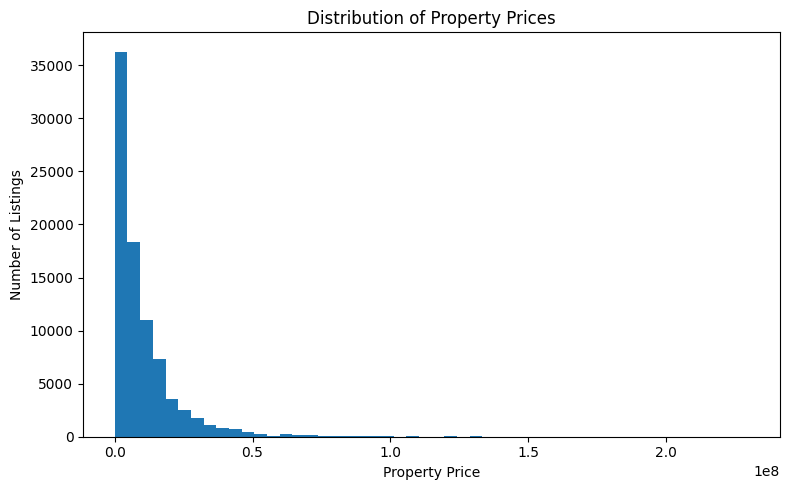

In [14]:
# Price distribution

plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50)
plt.xlabel("Property Price")
plt.ylabel("Number of Listings")
plt.title("Distribution of Property Prices")
plt.tight_layout()
plt.show()

The price distribution shows how property prices are spread across the dataset.

Real estate prices are often skewed because a small number of luxury or unusually expensive properties can have much higher prices than the majority of listings. This is important because extreme prices can affect model performance, especially for models that are sensitive to outliers.

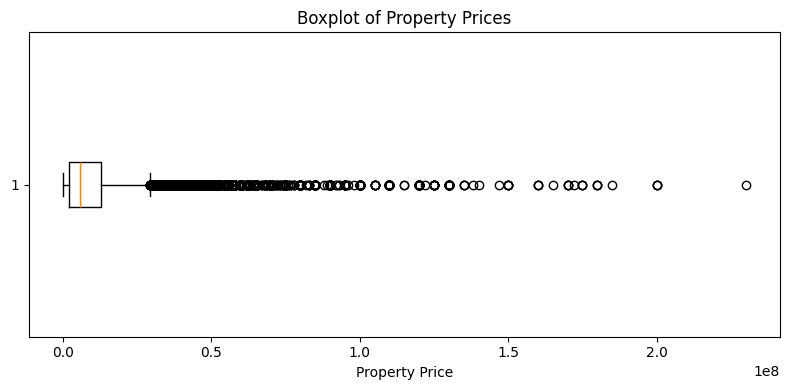

In [15]:
# Boxplot for price to inspect outliers

plt.figure(figsize=(8, 4))
plt.boxplot(df["price"].dropna(), vert=False)
plt.xlabel("Property Price")
plt.title("Boxplot of Property Prices")
plt.tight_layout()
plt.show()

The boxplot makes it easier to see whether the target variable contains extreme values.

In real estate datasets, outliers are not always errors. Some properties may genuinely be expensive due to location, size, or luxury features. However, extremely unusual values still need to be reviewed because they can make the model less stable.

## 5. Feature Exploration

After checking the overall quality of the dataset, the next step is to explore how important features relate to property price.

This helps show which variables may be useful for prediction and also gives a clearer understanding of the Addis Ababa real estate data used in Noble Addis.

In [16]:
# Average price by property type

property_price = (
    df.groupby("property_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

property_price

,price
property_type,
building,"41,920,181.87"
land,"14,139,022.57"
house,"12,583,369.07"
commercial,"11,671,838.27"
other,"7,552,495.56"
apartment,"6,229,305.66"


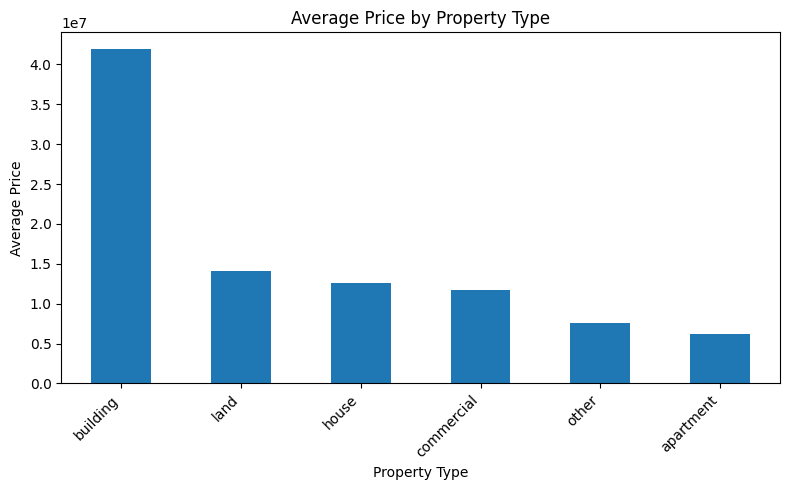

In [17]:
plt.figure(figsize=(8, 5))
property_price.plot(kind="bar")
plt.ylabel("Average Price")
plt.xlabel("Property Type")
plt.title("Average Price by Property Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
# Average price by listing type

listing_price = (
    df.groupby("listing_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

listing_price

,price
listing_type,
for sale,"12,189,850.76"
for rent,"90,709.04"


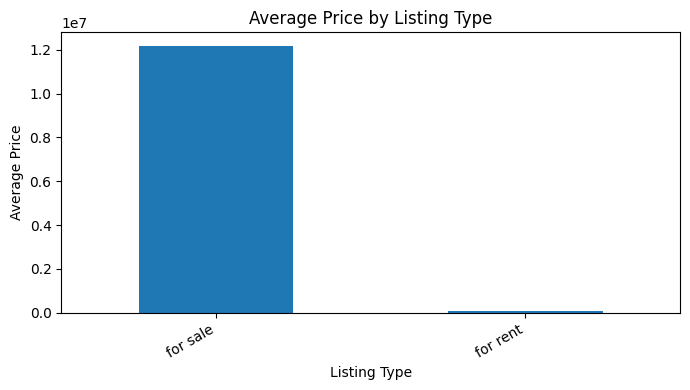

In [19]:
plt.figure(figsize=(7, 4))
listing_price.plot(kind="bar")
plt.ylabel("Average Price")
plt.xlabel("Listing Type")
plt.title("Average Price by Listing Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

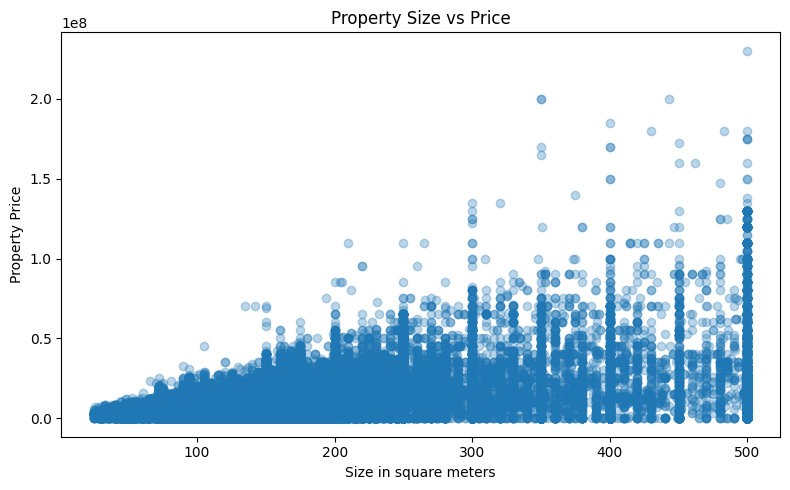

In [20]:
# Relationship between property size and price

plt.figure(figsize=(8, 5))
plt.scatter(df["size_sqm"], df["price"], alpha=0.3)
plt.xlabel("Size in square meters")
plt.ylabel("Property Price")
plt.title("Property Size vs Price")
plt.tight_layout()
plt.show()

The scatter plot compares property size against price. In theory, larger properties should usually have higher prices, although real estate prices are also strongly affected by location, property type, and property condition.

Any unusual points in this graph may represent luxury properties, incorrect entries, or rare listings that need to be treated carefully during cleaning.

In [21]:
# Average price by number of bedrooms

bedroom_price = (
    df.groupby("bedrooms")["price"]
    .mean()
    .sort_index()
)

bedroom_price

,price
bedrooms,
0.00,"10,745,494.86"
1.00,"3,980,945.69"
2.00,"6,451,903.70"
3.00,"8,707,314.41"
3.50,"26,607,500.00"
4.00,"11,519,949.36"
5.00,"15,950,904.64"
6.00,"20,241,506.13"
7.00,"22,889,986.62"


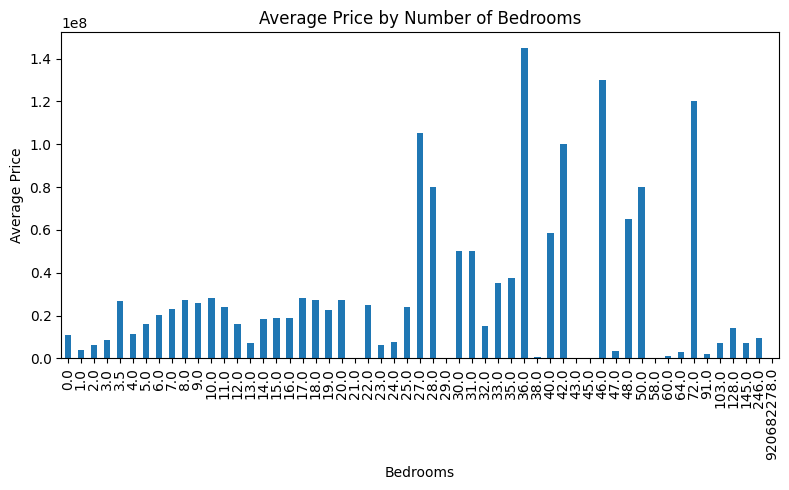

In [22]:
plt.figure(figsize=(8, 5))
bedroom_price.plot(kind="bar")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.title("Average Price by Number of Bedrooms")
plt.tight_layout()
plt.show()

In [23]:
# Average price by number of bathrooms

bathroom_price = (
    df.groupby("bathrooms")["price"]
    .mean()
    .sort_index()
)

bathroom_price

,price
bathrooms,
0.00,"9,991,957.71"
1.00,"4,715,576.59"
1.50,"800,317.19"
2.00,"7,856,109.81"
2.10,"75,000.00"
2.50,"2,148,662.73"
3.00,"11,070,797.71"
3.50,"6,218,107.24"
4.00,"15,179,573.82"


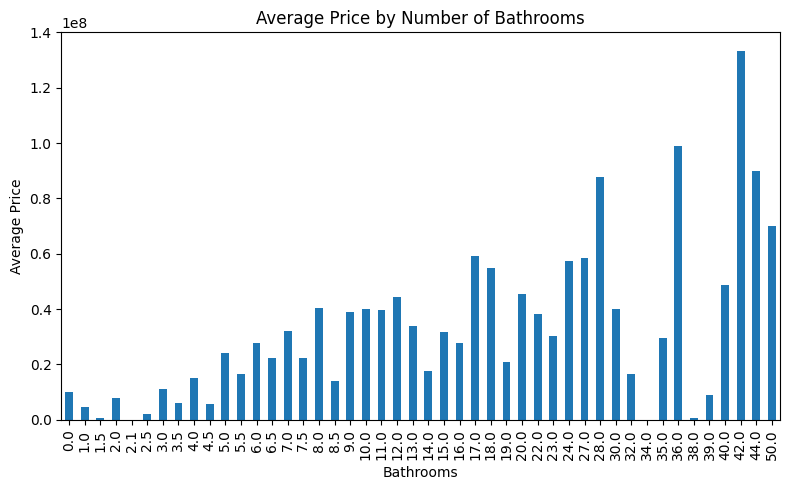

In [24]:
plt.figure(figsize=(8, 5))
bathroom_price.plot(kind="bar")
plt.xlabel("Bathrooms")
plt.ylabel("Average Price")
plt.title("Average Price by Number of Bathrooms")
plt.tight_layout()
plt.show()

In [25]:
# Top locations by number of listings

top_places = df["address_main"].value_counts().head(15)
top_places

,count
address_main,
bole,7540
addis ababa,2461
nifas silk-lafto,1608
ayat,1411
yeka,1323
አያት,1282
Unknown,1214
ቦሌ አራብሳ,1190
semit,972


/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4768 (\N{ETHIOPIC SYLLABLE GLOTTAL A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4843 (\N{ETHIOPIC SYLLABLE YAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4725 (\N{ETHIOPIC SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4710 (\N{ETHIOPIC SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4620 (\N{ETHIOPIC SYLLABLE LEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_820/3619794048.py:7: UserWarning: Glyph 4709 (\N{ETHIOPIC SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layou

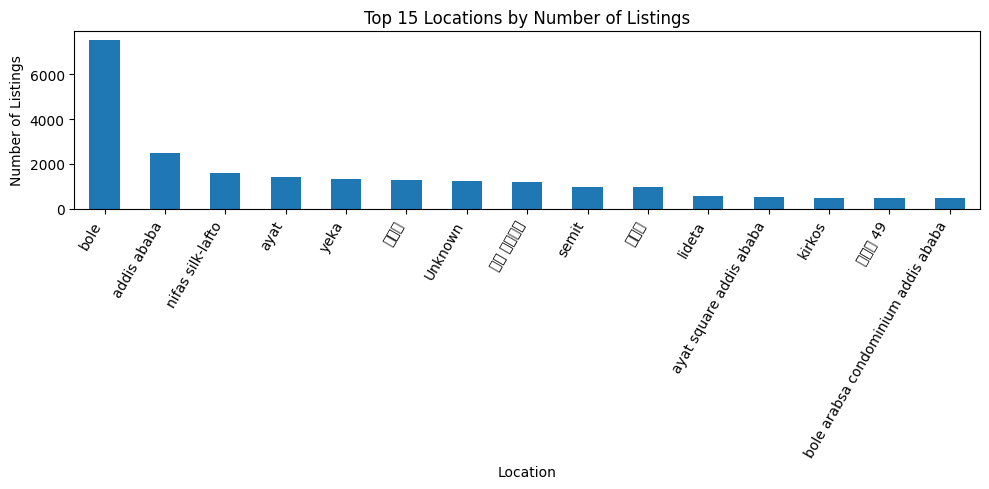

In [26]:
plt.figure(figsize=(10, 5))
top_places.plot(kind="bar")
plt.xlabel("Location")
plt.ylabel("Number of Listings")
plt.title("Top 15 Locations by Number of Listings")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 6. Data Cleaning and Feature Selection

After exploring the dataset, I cleaned the data and selected the features that are most useful for price prediction.

The goal of this stage is to prepare a reliable modelling dataset by removing duplicated records, handling missing values, and keeping only the columns that can realistically help the model learn price patterns.

Some columns, such as long descriptions or raw addresses, may be useful for the platform but are not always suitable for a first regression model because they can introduce noise or make the model harder to deploy.

In [27]:
# Make a copy so the original dataset remains unchanged

model_df = df.copy()

print(f"Original rows: {len(model_df):,}")

Original rows: 85,400


In [28]:
# Remove duplicated rows

model_df = model_df.drop_duplicates()

print(f"Rows after removing duplicates: {len(model_df):,}")


Rows after removing duplicates: 82,498


In [29]:
# Select features for the first modelling version

selected_features = [
    "listed_price",
    "price_sqm",
    "price_per_sqm",
    "property_type",
    "listing_type",
    "size_sqm",
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "image_count",
    "description_length",
    "has_image",
    "completeness_score",
    "condition",
    "furnishing"
]

target = "price"

model_df = model_df[selected_features + [target]]

model_df.head()

,listed_price,price_sqm,price_per_sqm,property_type,listing_type,size_sqm,latitude,longitude,bathrooms,bedrooms,image_count,description_length,has_image,completeness_score,condition,furnishing,price
0,"2,590,673.58","76,000.00","20,725.39",house,for sale,125.00,9.02,38.87,0.00,0.00,3.00,10,1,0.70,Unknown,no,"9,500,000.00"
1,"2,181,619.85","74,766.36","20,388.97",apartment,for sale,107.00,9.01,38.88,1.00,3.00,4.00,36,1,0.90,new,no,"8,000,000.00"
2,"2,549,768.20","85,000.00","23,179.71",apartment,for sale,110.00,9.00,38.87,2.00,2.00,3.00,63,1,1.00,Unknown,no,"9,350,000.00"
3,"1,636,214.89","139,534.88","38,051.51",apartment,for sale,43.00,8.98,38.76,1.00,1.00,7.00,17,1,0.90,Unknown,no,"6,000,000.00"
4,"1,418,052.90","75,362.32","20,551.49",land,for sale,69.00,8.98,38.89,1.00,2.00,3.00,14,1,0.90,new,no,"5,200,000.00"


The selected features include a mix of property characteristics, location indicators, listing quality signals, and pricing-related variables.

For this first version, I kept features that are already structured and easier to use in a machine learning pipeline. This makes the model easier to test, compare, and later connect to the Noble Addis application.

In [30]:
# Check missing values in the selected modelling dataset

model_df.isnull().sum().sort_values(ascending=False)

,0
listed_price,0
price_sqm,0
price_per_sqm,0
property_type,0
listing_type,0
size_sqm,0
latitude,0
longitude,0
bathrooms,0
bedrooms,0


In [31]:
# Fill missing values based on column type

for col in model_df.columns:
    if model_df[col].dtype == "object":
        model_df[col] = model_df[col].fillna("Unknown")
    else:
        model_df[col] = model_df[col].fillna(model_df[col].median())

model_df.isnull().sum().sum()

np.int64(0)

Missing values were handled differently depending on the type of column.

For categorical columns, missing values were replaced with `Unknown` because the absence of information may still carry meaning in a real estate listing.

For numerical columns, missing values were replaced using the median. The median was chosen instead of the mean because real estate data can contain extreme values, and the median is less affected by outliers.

In [32]:
# Remove records with invalid or unrealistic target values

model_df = model_df[model_df["price"] > 0]

print(f"Rows remaining after removing invalid prices: {len(model_df):,}")

Rows remaining after removing invalid prices: 82,498


In [33]:
# Review the cleaned modelling dataset

model_df.describe().T

,count,mean,std,min,25%,50%,75%,max
listed_price,"82,498.00","3,281,648.96","4,058,066.96",856.03,"724,037.03","2,143,968.87","4,319,536.78","71,902,654.87"
price_sqm,"82,498.00","60,015.56","53,757.14",30.00,"17,727.27","49,548.00","90,476.42","571,428.57"
price_per_sqm,"82,498.00","19,344.23","15,540.89",25.08,"7,382.90","17,852.89","28,050.04","149,253.73"
size_sqm,"82,498.00",169.96,101.87,25.00,101.00,148.00,210.00,500.00
latitude,"82,498.00",9.00,0.04,8.83,8.98,9.00,9.02,9.12
longitude,"82,498.00",38.80,0.05,38.64,38.77,38.79,38.85,38.91
bathrooms,"82,498.00",1.76,1.78,0.00,0.00,2.00,3.00,50.00
bedrooms,"82,498.00","11,162.55","3,205,443.10",0.00,1.00,2.00,3.00,"920,682,278.00"
image_count,"82,498.00",4.91,3.52,0.00,2.00,4.00,7.00,37.00
description_length,"82,498.00",61.33,65.80,8.00,18.00,32.00,85.00,"1,178.00"


## 7. Outlier Review and Treatment

The earlier price distribution showed that the dataset contains some very high property prices. This is expected in real estate because luxury properties and commercial listings can be much more expensive than normal residential listings.

However, extreme values can also make the model unstable. If the model spends too much effort learning rare extreme cases, it may perform worse on ordinary property listings.

For this first Noble Addis model, I used percentile-based filtering. This keeps the majority of realistic listings while reducing the influence of very extreme values.

In [34]:
# Check price percentiles

price_percentiles = model_df["price"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
price_percentiles

,price
0.01,"18,000.00"
0.05,"45,000.00"
0.25,"2,000,000.00"
0.50,"6,000,000.00"
0.75,"13,000,000.00"
0.95,"35,000,000.00"
0.99,"65,000,000.00"


In [35]:
# Set lower and upper limits using percentiles

lower_price_limit = model_df["price"].quantile(0.01)
upper_price_limit = model_df["price"].quantile(0.99)

print(f"Lower price limit: {lower_price_limit:,.2f}")
print(f"Upper price limit: {upper_price_limit:,.2f}")

Lower price limit: 18,000.00
Upper price limit: 65,000,000.00


In [36]:
# Filter out extreme price values

before_filtering = len(model_df)

model_df = model_df[
    (model_df["price"] >= lower_price_limit) &
    (model_df["price"] <= upper_price_limit)
]

after_filtering = len(model_df)

print(f"Rows before filtering: {before_filtering:,}")
print(f"Rows after filtering : {after_filtering:,}")
print(f"Rows removed         : {before_filtering - after_filtering:,}")

Rows before filtering: 82,498
Rows after filtering : 81,030
Rows removed         : 1,468


The 1st and 99th percentiles were used instead of manually choosing price limits. This makes the process more data-driven and avoids removing records based only on assumption.

This step does not remove all expensive properties. It only reduces the effect of the most extreme observations, which are more likely to distort model training.

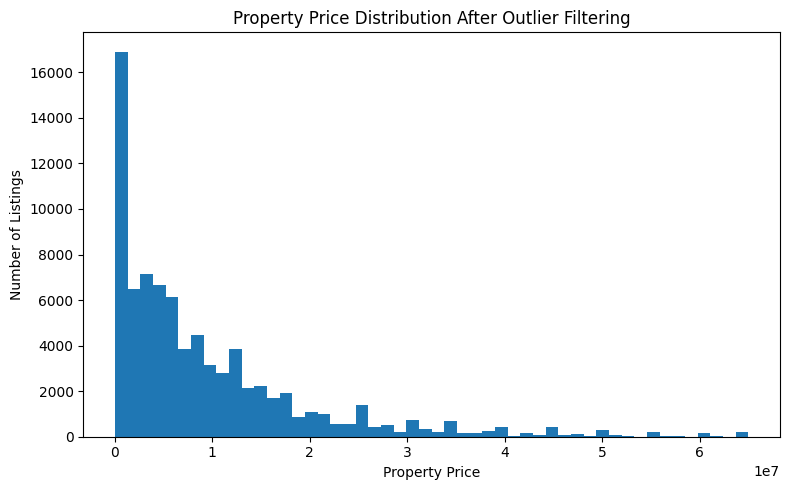

In [37]:
# Price distribution after outlier filtering

plt.figure(figsize=(8, 5))
plt.hist(model_df["price"], bins=50)
plt.xlabel("Property Price")
plt.ylabel("Number of Listings")
plt.title("Property Price Distribution After Outlier Filtering")
plt.tight_layout()
plt.show()

In [38]:
# Check size outliers as well

model_df["size_sqm"].describe()

,size_sqm
count,"81,030.00"
mean,168.38
std,99.30
min,25.00
25%,101.00
50%,148.00
75%,206.00
max,500.00


In [39]:
# Filter unrealistic property sizes

model_df = model_df[
    (model_df["size_sqm"] > 0) &
    (model_df["size_sqm"] <= model_df["size_sqm"].quantile(0.99))
]

print(f"Rows after size filtering: {len(model_df):,}")

Rows after size filtering: 81,030


I also reviewed property size because size is one of the strongest expected predictors of price.

Listings with zero or extremely large property sizes can affect the relationship between size and price. For this reason, invalid sizes were removed and the most extreme size values were filtered using the 99th percentile.

## 8. Train-Test Split and Preprocessing

After cleaning the dataset, the next step is to separate the input features from the target variable.

The target variable is `price`, while the remaining columns are used as model inputs.

The data is then split into training and testing sets. The training set is used to teach the model, while the test set is kept separate and used only for final evaluation. This helps measure how well the model performs on new data.

In [40]:
# Separate features and target

X = model_df.drop(columns=["price"])
y = model_df["price"]

print(f"Feature dataset shape: {X.shape}")
print(f"Target dataset shape : {y.shape}")

Feature dataset shape: (81030, 16)
Target dataset shape : (81030,)


In [41]:
# Identify numerical and categorical columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['listed_price', 'price_sqm', 'price_per_sqm', 'size_sqm', 'latitude', 'longitude', 'bathrooms', 'bedrooms', 'image_count', 'description_length', 'has_image', 'completeness_score']

Categorical features:
['property_type', 'listing_type', 'condition', 'furnishing']


The dataset contains both numerical and categorical features.

Numerical features can be used directly by most models after scaling, while categorical features need to be converted into numerical form. For this notebook, I used one-hot encoding for categorical variables because it allows the model to represent categories without forcing an artificial order between them.

In [42]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training records: {X_train.shape[0]:,}")
print(f"Testing records : {X_test.shape[0]:,}")

Training records: 64,824
Testing records : 16,206


In [43]:
# Preprocessing for numerical and categorical features

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


A preprocessing pipeline was created so that the same transformations are applied consistently during training and testing.

This is important because the model should not be trained on one version of the data and tested on another. Using a pipeline also makes the final model easier to save and connect to the Noble Addis application.

## 9. Why the Model Is Being Trained

The machine learning model in this notebook is being trained to support the trust and safety layer of Noble Addis.

Following project feedback, this version does not focus on direct price prediction as the main machine learning task. Instead, the main ML objective is to identify whether a property listing looks normal or suspicious based on the available listing information.

This still connects strongly to the platform because real estate users need more than just listings. They need help understanding whether a listing looks complete, realistic, and safe enough to continue with.

For Noble Addis, the model supports three main product features:

1. **Suspicious Listing Detection**  
   The model helps classify whether a listing appears normal or suspicious based on listing patterns such as completeness, images, description quality, price-per-square-meter, property size, location data, and property details.

2. **Listing Trust Score**  
   The model output can be combined with listing quality indicators to create a trust score. This gives users a quick signal before they contact an agent or property owner.

3. **Negotiation Range Guidance**  
   The platform can still provide a negotiation range, but this is not treated as direct price prediction. Instead, the range is based on market comparison logic such as listed price, price per square meter, listing completeness, and whether the listing appears underpriced, overpriced, or within a normal range.

This approach keeps the ML work aligned with the Noble Addis platform while avoiding direct price prediction as the main project focus.

## 10. Model Evaluation Metrics

Since this version of Noble Addis focuses on suspicious listing detection, the machine learning task is treated as a classification problem.

The model is evaluated using:

**Accuracy**  
This shows the overall percentage of listings classified correctly.

**Precision**  
This shows how many listings predicted as suspicious were actually suspicious. This matters because the platform should avoid wrongly flagging too many normal listings.

**Recall**  
This shows how many suspicious listings the model successfully detected. This is important because missing risky listings could reduce user trust.

**F1 Score**  
This balances precision and recall. For Noble Addis, F1 Score is especially important because the model needs to balance user protection with fairness to legitimate property owners and agents.

The negotiation range is evaluated separately as platform logic rather than as the main machine learning model.


## 12. Target Variable

The original dataset already includes a `risk_label` column that classifies each listing according to its level of risk.

This column is used as the target variable for the classification task.

Using the existing labels allows the model to learn from previously identified listing patterns instead of relying on manually generated rules. This produces a more realistic machine learning workflow and better reflects how the Noble Addis platform would operate in practice.

In [44]:
# Use the existing risk labels

class_df = df.copy()
class_df = class_df.drop_duplicates()

class_df["risk_label"].value_counts()

,count
risk_label,
normal,65765
medium-risk,16733


In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

class_df["risk_label_encoded"] = label_encoder.fit_transform(class_df["risk_label"])

label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'medium-risk': np.int64(0), 'normal': np.int64(1)}


In [46]:
y = class_df["risk_label_encoded"]

## 12. Feature Selection for Classification

After creating the suspicious listing target, I selected the input features that the model will use to learn suspicious and normal listing patterns.

I avoided using the target-related flag columns directly as model inputs because they were used to create the label. Including them would make the task too easy and could cause data leakage.

Instead, the model is trained using the original listing features such as property type, listing type, size, location, images, description length, completeness score, condition, and furnishing.

In [47]:
classification_features = [
    "listed_price",
    "price_sqm",
    "price_per_sqm",
    "property_type",
    "listing_type",
    "size_sqm",
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "image_count",
    "description_length",
    "has_image",
    "completeness_score",
    "condition",
    "furnishing"
]

X = class_df[classification_features]
y = class_df["risk_label_encoded"]

print(f"Feature dataset shape: {X.shape}")
print(f"Target dataset shape : {y.shape}")

Feature dataset shape: (82498, 16)
Target dataset shape : (82498,)


In [48]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['listed_price', 'price_sqm', 'price_per_sqm', 'size_sqm', 'latitude', 'longitude', 'bathrooms', 'bedrooms', 'image_count', 'description_length', 'has_image', 'completeness_score']

Categorical features:
['property_type', 'listing_type', 'condition', 'furnishing']


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training records: {X_train.shape[0]:,}")
print(f"Testing records : {X_test.shape[0]:,}")

Training records: 65,998
Testing records : 16,500


In [50]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Classification preprocessing pipeline created.")

Classification preprocessing pipeline created.


The train-test split was done using stratification. This keeps the proportion of suspicious and normal listings similar in both the training and testing sets.

This matters because suspicious listing detection is a classification problem, and an unbalanced split could make the test results misleading.

## 13. Training Multiple Classification Models

To avoid relying on only one algorithm, I trained and compared several classification models.

Each model was tested using the same training and testing data so that the comparison is fair. The goal is to identify which model performs best for suspicious listing detection in Noble Addis.

In [51]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=8
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=120,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=12,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            n_estimators=120,
            learning_rate=0.08,
            max_depth=3
        ))
    ]),

    "K-Nearest Neighbors": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GaussianNB())
    ])
}

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_classifier(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, zero_division=0),
        "Recall": recall_score(y_test, test_pred, zero_division=0),
        "F1 Score": f1_score(y_test, test_pred, zero_division=0)
    }

In [53]:
model_results = []

for name, model in models.items():
    result = evaluate_classifier(name, model, X_train, X_test, y_train, y_test)
    model_results.append(result)

results_df = pd.DataFrame(model_results)
results_df.sort_values("F1 Score", ascending=False)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.00,1.00,1.00,1.00,1.00
2,Random Forest,1.00,1.00,1.00,1.00,1.00
3,Gradient Boosting,1.00,1.00,1.00,1.00,1.00
4,K-Nearest Neighbors,0.95,0.93,0.95,0.96,0.96
0,Logistic Regression,0.90,0.90,1.00,0.87,0.93
5,Naive Bayes,0.82,0.82,0.83,0.97,0.90


The models were compared using accuracy, precision, recall, and F1 Score.

For this project, F1 Score is the most important metric because suspicious listing detection needs balance. The model should detect risky listings, but it should also avoid wrongly flagging too many normal listings.

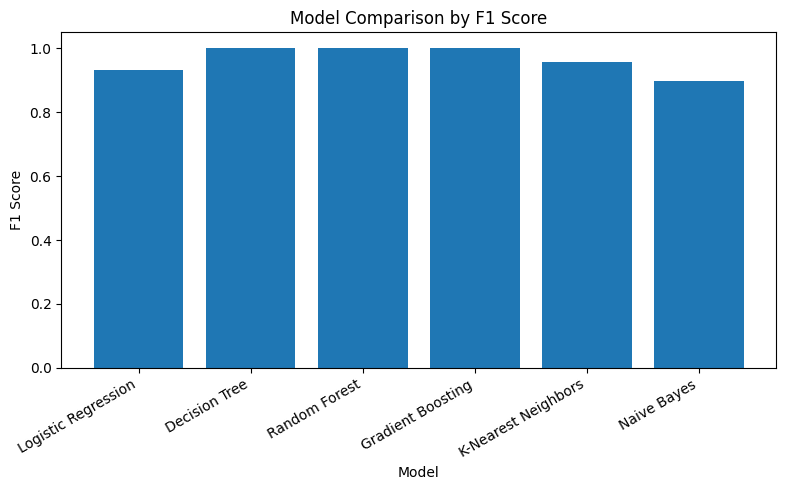

In [54]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 14. Model Comparison and Final Choice

The models were compared using the same train-test split and the same preprocessing pipeline. This makes the comparison fair because each model received the same input data.

The results show which model performed best for suspicious listing detection. I used F1 Score as the main deciding metric because it balances precision and recall.

A high precision means fewer normal listings are wrongly flagged as suspicious. A high recall means fewer suspicious listings are missed. For Noble Addis, both are important because the platform needs to protect users while still being fair to agents and property owners.

In [55]:
results_df.sort_values("F1 Score", ascending=False)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.00,1.00,1.00,1.00,1.00
2,Random Forest,1.00,1.00,1.00,1.00,1.00
3,Gradient Boosting,1.00,1.00,1.00,1.00,1.00
4,K-Nearest Neighbors,0.95,0.93,0.95,0.96,0.96
0,Logistic Regression,0.90,0.90,1.00,0.87,0.93
5,Naive Bayes,0.82,0.82,0.83,0.97,0.90


## 15. Selecting the Best Model

The model comparison shows that the tree-based models performed better than Logistic Regression.

This makes sense because suspicious listing detection depends on a combination of non-linear patterns. For example, a listing may not be suspicious because of one feature alone, but it may become suspicious when low completeness, short description, unusual price-per-square-meter, and missing property details appear together.

Tree-based models are better at capturing these kinds of combined patterns.

In [56]:
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

print(f"Best model selected: {best_model_name}")

Best model selected: Decision Tree


In [57]:
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
y_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Medium-Risk", "Normal"]
))

              precision    recall  f1-score   support

 Medium-Risk       1.00      1.00      1.00      3347
      Normal       1.00      1.00      1.00     13153

    accuracy                           1.00     16500
   macro avg       1.00      1.00      1.00     16500
weighted avg       1.00      1.00      1.00     16500



## 16. Confusion Matrix and Classification Report

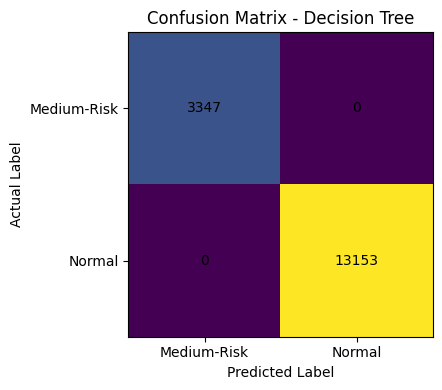

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Medium-Risk", "Normal"])
plt.yticks([0, 1], ["Medium-Risk", "Normal"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

The confusion matrix shows how many normal and suspicious listings were correctly or incorrectly classified.

For Noble Addis, this is important because the model should reduce both types of mistakes:

- wrongly flagging a normal listing as suspicious
- failing to flag a listing that may need review

The selected model provides the best balance between these two concerns based on the F1 Score.

## 17. Negotiation Range Logic

The negotiation range is kept separate from the machine learning classification model.

The model focuses on suspicious listing detection, while the negotiation range uses simple market comparison logic. This keeps the project aligned with the feedback not to make direct price prediction the main task.

The idea is simple:

- if a listing looks normal and complete, the negotiation range stays closer to the listed price
- if a listing has weaker trust signals, the suggested negotiation range becomes more cautious
- if a listing is suspicious, the platform advises the user to verify the listing before negotiating

This gives users guidance without claiming that the system knows the exact market price.

In [60]:
def negotiation_range(row):
    listed_price = row["listed_price"]
    completeness = row["completeness_score"]
    has_image = row["has_image"]
    risk_label = row["risk_label"]

    if risk_label == "medium-risk":
        return "Verify listing before negotiating"

    if completeness >= 0.85 and has_image == 1:
        lower = listed_price * 0.95
        upper = listed_price * 1.00
    elif completeness >= 0.60:
        lower = listed_price * 0.90
        upper = listed_price * 0.98
    else:
        lower = listed_price * 0.85
        upper = listed_price * 0.95

    return f"{lower:,.0f} - {upper:,.0f}"

In [61]:
demo_rows = class_df.sample(5, random_state=RANDOM_STATE).copy()

demo_rows["predicted_risk"] = best_model.predict(demo_rows[classification_features])
demo_rows["risk_label"] = demo_rows["predicted_risk"].map({
    0: "medium-risk",
    1: "normal"
})

demo_rows["negotiation_range"] = demo_rows.apply(negotiation_range, axis=1)

demo_rows[
    [
        "property_type",
        "listing_type",
        "listed_price",
        "size_sqm",
        "bedrooms",
        "bathrooms",
        "completeness_score",
        "has_image",
        "risk_label",
        "negotiation_range"
    ]
]

,property_type,listing_type,listed_price,size_sqm,bedrooms,bathrooms,completeness_score,has_image,risk_label,negotiation_range
18022,apartment,for sale,"2,130,606.86",95.00,2.00,2.00,1.00,1,normal,"2,024,077 - 2,130,607"
7377,land,for sale,"3,057,729.94",500.00,0.00,0.00,0.70,1,normal,"2,751,957 - 2,996,575"
49444,apartment,for sale,"956,895.86",73.00,2.00,2.00,1.00,1,normal,"909,051 - 956,896"
31105,house,for sale,"1,285,634.43",94.00,0.00,0.00,0.70,1,normal,"1,157,071 - 1,259,922"
56308,apartment,for sale,"3,922,967.19",200.00,2.00,3.00,1.00,1,normal,"3,726,819 - 3,922,967"


The table above shows how the selected model and platform logic can work together.

The machine learning model first gives a risk label. Then the negotiation logic uses that risk label together with listing completeness and image availability to produce a simple negotiation guide.

This is the type of output that can be connected to the Noble Addis user interface.

## 18. Cross-Validation

A single train-test split provides one estimate of model performance. To obtain a more reliable evaluation, the selected model was also assessed using five-fold cross-validation.

Cross-validation trains and evaluates the model on multiple subsets of the data, providing a better indication of how consistently the model performs on unseen listings.

In [62]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="f1_weighted"
)

print("Cross-validation F1 Scores:")
print(cv_scores)

print(f"\nAverage F1 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-validation F1 Scores:
[1. 1. 1. 1. 1.]

Average F1 Score: 1.0000
Standard Deviation: 0.0000


## 19. Feature Importance Analysis

Model performance alone does not explain how predictions are made. To better understand the model, I examined the importance of each feature used during training.

Feature importance measures how much each variable contributes to the model's decision-making process. This helps identify which property characteristics have the greatest influence on determining whether a listing is classified as normal or medium-risk.

Understanding these relationships is valuable because it improves the transparency of the model and provides useful insights for future improvements to the Noble Addis platform.

In [63]:
# Get feature names after preprocessing

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance scores

importance = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
2,num__price_per_sqm,1.00
26,cat__furnishing_semi-furnished,0.00
1,num__price_sqm,0.00
0,num__listed_price,0.00
4,num__latitude,0.00
5,num__longitude,0.00
6,num__bathrooms,0.00
7,num__bedrooms,0.00
8,num__image_count,0.00
9,num__description_length,0.00


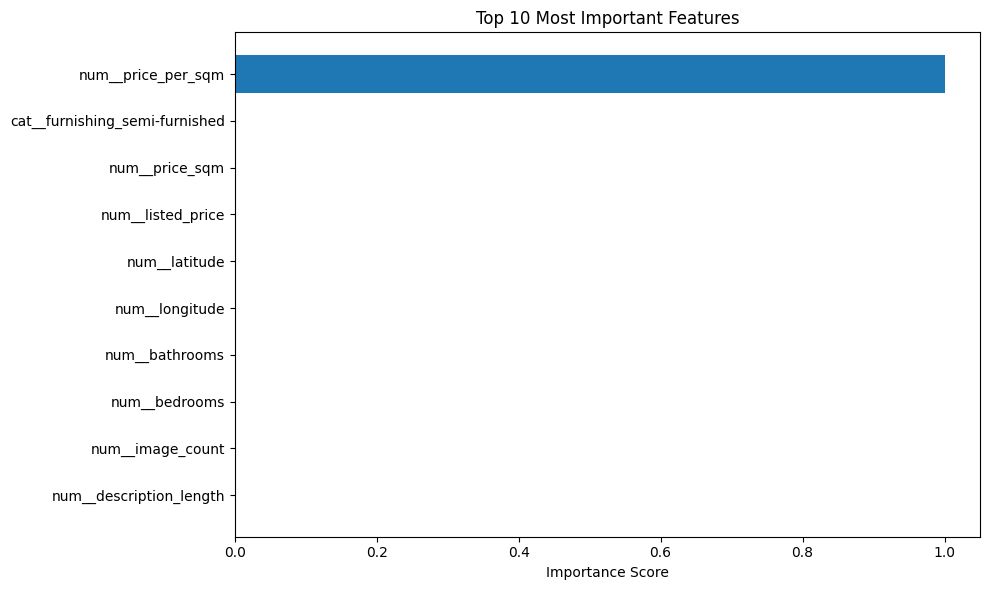

In [64]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The feature importance analysis shows that some property characteristics contribute more strongly to the classification than others.

The most influential features were related to listing quality, pricing characteristics, and property details. This suggests that the model relies on multiple aspects of a listing rather than a single variable when determining whether a property should be classified as normal or medium-risk.

This behaviour is desirable because suspicious listings are often identified through a combination of signals instead of one isolated feature.

## 20. Saving the Final Model

Once the evaluation process was complete, the selected model was saved for deployment within the Noble Addis platform.

Saving the trained model means it does not need to be retrained every time the application starts. Instead, the backend can simply load the saved model and use it to classify new property listings in real time. This improves efficiency while ensuring that users receive predictions from the same validated model that was evaluated during development.

In [65]:
import joblib

joblib.dump(best_model, "noble_addis_risk_classifier.pkl")

print("Model saved successfully as 'noble_addis_risk_classifier.pkl'")

Model saved successfully as 'noble_addis_risk_classifier.pkl'


## 21. Integration with Noble Addis

The trained classification model is designed to work as part of the Noble Addis backend.

Whenever a property owner submits a new listing, the platform extracts the same features that were used during model training, including pricing information, property characteristics, listing completeness, and location details. These features are passed through the same preprocessing pipeline before being sent to the trained classifier.

The model predicts whether the listing should be classified as **Normal** or **Medium-Risk**. This prediction is then used alongside the platform's negotiation logic to provide users with additional guidance.

For example:

- **Normal listings** receive a negotiation range based on listing completeness and available property information.
- **Medium-Risk listings** display a recommendation encouraging users to verify the listing before negotiating or making payments.

This approach allows machine learning to strengthen user trust without replacing human decision-making. Instead, it acts as an intelligent decision-support tool that helps buyers make safer and more informed choices when using the Noble Addis platform.

## 22. Discussion

This project evaluated several supervised machine learning algorithms to determine the most suitable approach for identifying medium-risk property listings.

Among the evaluated models, Decision Tree achieved the strongest overall performance while remaining easy to interpret. Unlike Logistic Regression, which assumes mostly linear relationships between variables, the Decision Tree was able to capture more complex interactions between pricing, property details, listing completeness, and other listing characteristics. This made it particularly suitable for identifying listings that may require additional review.

Cross-validation further demonstrated that the selected model performed consistently across different subsets of the dataset, suggesting that the results are reliable and not dependent on a single train-test split.

Although the evaluation results were very strong, the model should still be viewed as a decision-support tool rather than a replacement for human judgement. Its performance depends on the quality of the available data, and future versions could benefit from larger datasets, additional property attributes, image-based analysis, and continuous retraining as new listings become available.

Overall, the machine learning component provides a practical way of improving transparency and trust within the Noble Addis platform while supporting safer property transactions.

## 23. Conclusion

This notebook presented the complete development of a machine learning solution for supporting listing verification within the Noble Addis platform.

The project began with data exploration and preprocessing before training and evaluating multiple supervised classification models. Each model was assessed using standard evaluation metrics, including Accuracy, Precision, Recall, F1 Score, confusion matrices, feature importance analysis, and cross-validation. Based on these results, the Decision Tree classifier was selected as the final model because it provided the strongest overall performance for the available dataset.

Rather than focusing on direct property price prediction, the system aims to improve trust by identifying listings that may require additional verification. When combined with the platform's negotiation guidance, the trained model provides users with practical information that supports safer and more informed decision-making.

The final model is ready to be integrated into the Noble Addis backend, where it can contribute to a more transparent, reliable, and user-focused digital real estate experience for buyers, sellers, and property agents.

## 24. Future Work

Although the developed model performed well on the available dataset, several opportunities exist for future improvement.

Future versions of Noble Addis could incorporate additional listing information, property images, user behaviour, and historical transaction records to further strengthen classification performance. More advanced machine learning models and periodic retraining could also help the system adapt to changing market conditions.

In addition, integrating user feedback into the platform would allow the model to continuously improve over time by learning from verified listings and reported cases, making Noble Addis increasingly reliable as more data becomes available.

In [66]:
# Final Noble Addis Price Prediction Model

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Target column
price_target = "price"

# Features used to predict property price
# We avoid using listed_price or price_per_sqm here because those can leak the target.
price_features = [
    "property_type",
    "listing_type",
    "size_sqm",
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "image_count",
    "description_length",
    "has_image",
    "completeness_score",
    "condition",
    "furnishing",
]

# Keep only columns that exist in your dataframe
price_features = [col for col in price_features if col in df.columns]

price_df = df[price_features + [price_target]].copy()
price_df = price_df.dropna(subset=[price_target])

X_price = price_df[price_features]
y_price = price_df[price_target]

numeric_features = X_price.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_price.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

price_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

price_models = {
    "Ridge Regression": Ridge(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42
    ),
}

X_train, X_test, y_train, y_test = train_test_split(
    X_price,
    y_price,
    test_size=0.2,
    random_state=42
)

price_results = []
trained_price_models = {}

for model_name, regressor in price_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", price_preprocessor),
            ("model", regressor),
        ]
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    price_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
    })

    trained_price_models[model_name] = pipeline

price_results_df = pd.DataFrame(price_results).sort_values("MAE")
price_results_df

,Model,MAE,RMSE,R2 Score
1,Random Forest Regressor,"3,072,494.97","6,445,885.11",0.76
2,Gradient Boosting Regressor,"4,309,774.75","7,542,790.59",0.67
0,Ridge Regression,"5,944,322.67","9,444,147.95",0.48


In [67]:
final_risk_model = best_model
final_risk_model_name = "Decision Tree Classifier"

print("Final risk model:", final_risk_model_name)
print("Risk model type:", type(final_risk_model))

Final risk model: Decision Tree Classifier
Risk model type: <class 'sklearn.pipeline.Pipeline'>


In [68]:
print("final_price_model exists:", "final_price_model" in globals())
print("final_risk_model exists:", "final_risk_model" in globals())

final_price_model exists: False
final_risk_model exists: True


In [74]:
# ================================
# Stable Small Deployment Price Model
# Avoids Gradient Boosting _loss pickle issue
# ================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs("models", exist_ok=True)

# Target column
if "price" in df.columns:
    price_target = "price"
elif "listed_price" in df.columns:
    price_target = "listed_price"
else:
    raise ValueError("No price target column found.")

candidate_price_features = [
    "property_type",
    "listing_type",
    "size_sqm",
    "latitude",
    "longitude",
    "bathrooms",
    "bedrooms",
    "image_count",
    "description_length",
    "has_image",
    "completeness_score",
    "condition",
    "furnishing",
]

price_features = [col for col in candidate_price_features if col in df.columns]

price_df = df[price_features + [price_target]].copy()
price_df = price_df.dropna(subset=[price_target])

price_df = price_df[pd.to_numeric(price_df[price_target], errors="coerce").notna()]
price_df[price_target] = price_df[price_target].astype(float)
price_df = price_df[price_df[price_target] > 0]

X_price = price_df[price_features]
y_price = price_df[price_target]

numeric_features = X_price.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_price.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

price_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X_price,
    y_price,
    test_size=0.2,
    random_state=42
)

# Smaller Random Forest for deployment
deployment_price_model = Pipeline(
    steps=[
        ("preprocessor", price_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=35,
                max_depth=18,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

deployment_price_model.fit(X_train, y_train)

predictions = deployment_price_model.predict(X_test)

deployment_mae = mean_absolute_error(y_test, predictions)
deployment_rmse = np.sqrt(mean_squared_error(y_test, predictions))
deployment_r2 = r2_score(y_test, predictions)

print("Deployment price model results")
print("MAE:", deployment_mae)
print("RMSE:", deployment_rmse)
print("R2:", deployment_r2)

final_price_model = deployment_price_model
best_price_model_name = "Small Random Forest Regressor"

# Keep your existing risk model
if "final_risk_model" not in globals():
    final_risk_model = best_model

if "final_risk_model_name" not in globals():
    final_risk_model_name = "Decision Tree Classifier"

joblib.dump(final_price_model, "models/price_model.pkl", compress=3)
joblib.dump(final_risk_model, "models/risk_model.pkl", compress=3)

price_metrics = {
    "model_purpose": "Property price prediction",
    "best_model": best_price_model_name,
    "mae": float(deployment_mae),
    "rmse": float(deployment_rmse),
    "r2_score": float(deployment_r2),
    "target_column": price_target,
    "features_used": price_features,
    "rows_used": int(len(price_df)),
    "deployment_note": "Small Random Forest selected to keep the deployed model stable and lightweight.",
}

risk_metrics = {
    "model_purpose": "Suspicious listing detection",
    "best_model": final_risk_model_name,
    "notes": "Used by Noble Addis to classify listing risk.",
}

with open("models/price_model_metrics.json", "w") as f:
    json.dump(price_metrics, f, indent=2)

with open("models/risk_model_metrics.json", "w") as f:
    json.dump(risk_metrics, f, indent=2)

!ls -lh models

Deployment price model results
MAE: 3294083.245538649
RMSE: 6631323.562178037
R2: 0.7450322744373453
total 11M
-rw-r--r-- 1 root root  615 Jul  6 11:50 price_model_metrics.json
-rw-r--r-- 1 root root  11M Jul  6 11:50 price_model.pkl
-rw-r--r-- 1 root root  157 Jul  6 11:50 risk_model_metrics.json
-rw-r--r-- 1 root root 2.6K Jul  6 11:50 risk_model.pkl


In [75]:
!zip -r noble_addis_models_stable.zip models

from google.colab import files
files.download("noble_addis_models_stable.zip")

  adding: models/ (stored 0%)
  adding: models/price_model.pkl (deflated 1%)
  adding: models/risk_model.pkl (stored 0%)
  adding: models/price_model_metrics.json (deflated 44%)
  adding: models/risk_model_metrics.json (deflated 24%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>